# 07 — The Mid-Season Exodus: does losing a star mid-season cost you?

Outcome = change in Elo-residual points (rest-of-season minus pre-window), so the differing second-half schedule is netted out. Because **almost every** club sells *someone* abroad each summer, 'sold vs didn't' is not a usable contrast — the signal, if any, is in *how much* is sold. So we test two things: a threshold-free **dose–response** (form change vs total fee sold abroad), and a **major-sale** event study across fee thresholds, each against its placebo floor.

In [1]:
from brasileirao import transfers, exodus, ingest, plotting
import matplotlib.pyplot as plt
import numpy as np, pandas as pd

plotting.style()
me = exodus.elo_expected_points(ingest.load())
fdep = transfers.build()
fdep = fdep[fdep.to_foreign]
panel = exodus.build_panel(fdep, me)          # treated = any summer sale abroad
print(f'club-seasons {len(panel)} | with a sale abroad {int(panel.treated.sum())} '
      f'({panel.treated.mean():.0%}) -> binary sold-vs-didn\'t is degenerate')
d = panel.copy(); d['dose_m'] = d['dose_eur'] / 1e6
r = np.corrcoef(np.log1p(d.dose_m), d.d_resid)[0, 1]
print(f'dose-response: Pearson r(log(1+fee_m), d_resid) over {len(d)} club-seasons = {r:+.3f}')

club-seasons 240 | with a sale abroad 235 (98%) -> binary sold-vs-didn't is degenerate
dose-response: Pearson r(log(1+fee_m), d_resid) over 240 club-seasons = -0.013


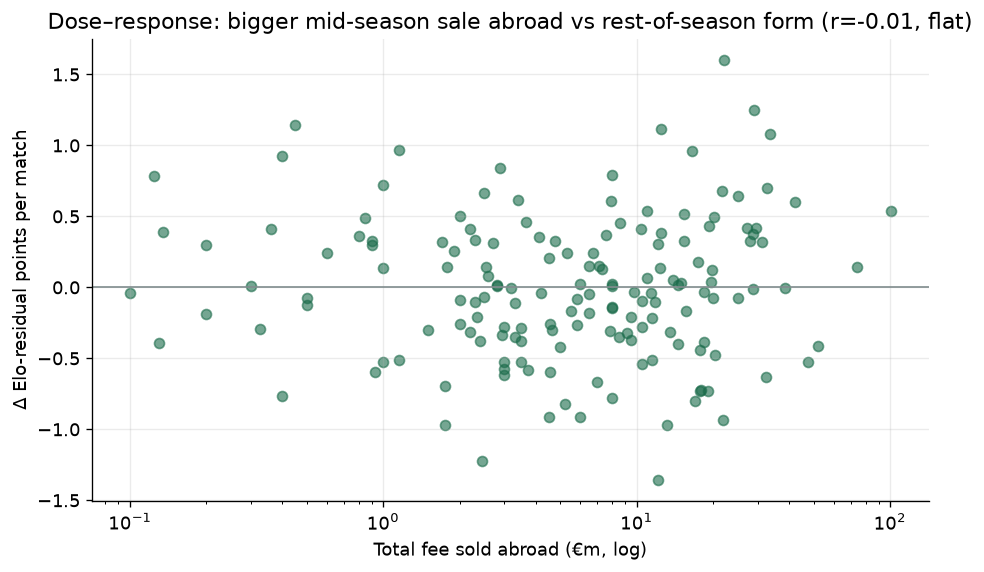

In [2]:
sub = d[d.dose_m > 0]
fig, ax = plt.subplots()
ax.scatter(sub.dose_m, sub.d_resid, color=plotting.COLORS['main'], alpha=0.6)
ax.set_xscale('log')
ax.axhline(0, color=plotting.COLORS['muted'], lw=1)
ax.set(title=f'Dose–response: bigger mid-season sale abroad vs rest-of-season form (r={r:+.2f}, flat)',
       xlabel='Total fee sold abroad (€m, log)', ylabel='Δ Elo-residual points per match')
plotting.save(fig, 'exodus_dose_response')

 thr_m  treated  control  effect     lo    hi  floor_lo  floor_hi    did
   2.0      127      113  -0.034 -0.119 0.054    -0.019     0.136 -0.131
   5.0       81      159  -0.012 -0.130 0.104    -0.076     0.115  0.001
  10.0       40      200   0.109 -0.069 0.288    -0.150     0.129  0.188


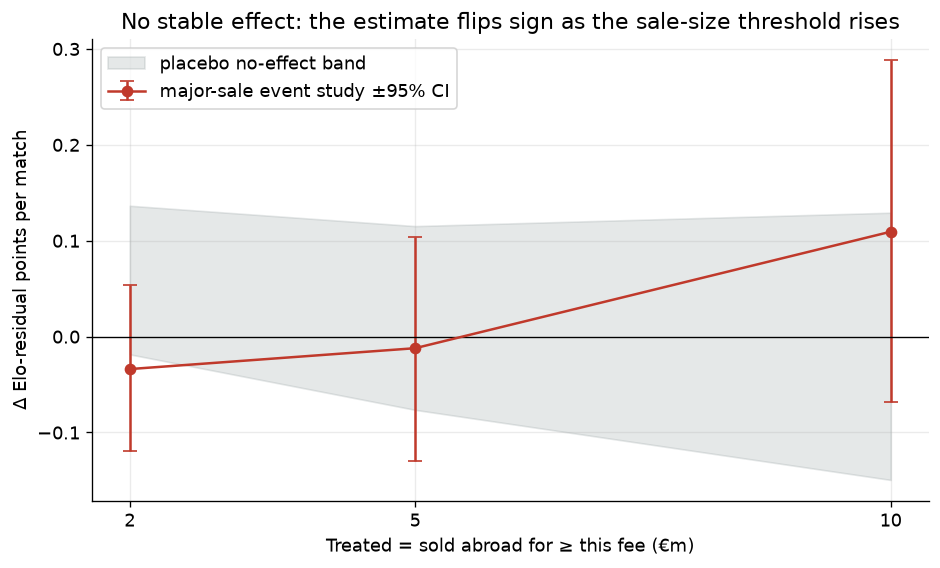

In [3]:
rows = []
for thr in [2e6, 5e6, 10e6]:
    p = exodus.build_panel(fdep[fdep.fee_eur >= thr], me)
    es, fl, dd = exodus.event_study(p), exodus.placebo_floor(p), exodus.did(p)
    rows.append(dict(thr_m=thr/1e6, treated=int(p.treated.sum()), control=int((~p.treated).sum()),
                     effect=es['mean_d_resid'], lo=es['ci_resid'][0], hi=es['ci_resid'][1],
                     floor_lo=fl['lo'], floor_hi=fl['hi'], did=dd['att']))
tbl = pd.DataFrame(rows)
print(tbl.round(3).to_string(index=False))
fig, ax = plt.subplots()
x = tbl.thr_m
ax.fill_between(x, tbl.floor_lo, tbl.floor_hi, color=plotting.COLORS['muted'], alpha=0.2,
                label='placebo no-effect band')
ax.errorbar(x, tbl.effect, yerr=[tbl.effect - tbl.lo, tbl.hi - tbl.effect], fmt='o-',
            color=plotting.COLORS['accent'], capsize=4, label='major-sale event study ±95% CI')
ax.axhline(0, color='k', lw=0.8)
ax.set(title='No stable effect: the estimate flips sign as the sale-size threshold rises',
       xlabel='Treated = sold abroad for ≥ this fee (€m)', ylabel='Δ Elo-residual points per match')
ax.set_xticks([2, 5, 10]); ax.legend()
plotting.save(fig, 'exodus_threshold_sensitivity')

In [4]:
flat_dose = abs(r) < 0.10
signs = np.sign(tbl.effect.values)
unstable = not (np.all(signs <= 0) or np.all(signs >= 0))
any_clears = bool(((tbl.effect < tbl.floor_lo) | (tbl.effect > tbl.floor_hi)).any())
if flat_dose and unstable:
    verdict = '(c) no detectable effect: dose-response is flat and the threshold estimate flips sign'
elif any_clears:
    verdict = '(a)/(b) an effect that clears the floor at some specification — inspect robustness'
else:
    verdict = '(c) no detectable effect beyond the placebo floor'
print('VERDICT:', verdict)

VERDICT: (c) no detectable effect: dose-response is flat and the threshold estimate flips sign
